In [53]:
import pandas as pd
import numpy as np
#import nltk
#nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
# Reads in the training data for SVM and splits
df = pd.read_csv('final_script/dataset_1_cleaned.csv', dtype=str)
x = df['text']
binary_y = df['Label']
x_bin_train, x_bin_test, y_bin_train, y_bin_test = train_test_split(x, binary_y, test_size=0.2, shuffle=True)

In [3]:
# Label counts (For graphing)
df['Label'].value_counts()

Label
0    26759
1    15823
Name: count, dtype: int64

In [4]:
# Vectorizes using TF-IDF
tfidf = TfidfVectorizer()
bin_train_vals = tfidf.fit_transform(x_bin_train.to_numpy(dtype=str))
bin_test_vals = tfidf.transform(x_bin_test.to_numpy(dtype=str))

In [5]:
# SVM Classifier for binary classification
svm_bin = LinearSVC()
svm_bin.fit(bin_train_vals, y_bin_train.to_numpy(dtype=int))
svm_bin_preds = svm_bin.predict(bin_test_vals)

print('Recall:', recall_score(y_bin_test.to_numpy(dtype=int), svm_bin_preds), 'Precision:', precision_score(y_bin_test.to_numpy(dtype=int), svm_bin_preds))
print('F1 Score:', f1_score(y_bin_test.to_numpy(dtype=int), svm_bin_preds))

Recall: 0.9628814092481912 Precision: 0.9877379799935463
F1 Score: 0.9751513220770947


In [6]:
# Reads in "Big Tweet" data set
df_2 = pd.read_csv('final_script/bluesky_posts_all.csv', dtype=str)
len(df_2)

121617

In [7]:
# Transforms and predicts using the SVM model
transformed_text = tfidf.transform(df_2['text'].to_numpy(dtype=str))
classification = svm_bin.predict(transformed_text)

In [23]:
# Adds the label to the dataframe
df_2.loc[:, 'labels'] = classification

# Creates the educators dataset, made up of "target" tweets from the "Big Tweet" dataset
#df_3 = df_2[df_2['labels'] == 1]
#df_3.to_csv('final_script/educators.csv', index=False)
df_3 = pd.read_csv('final_script/educators.csv', dtype=str)

df_3['created_at'] = pd.to_datetime(df_3['created_at'], format='ISO8601', utc=True)
len(df_3)

16087

In [24]:
# Uses VADER for sentiment analysis
analyzer = SentimentIntensityAnalyzer()

sentiments = []
for i in df_3['text']:
    sentiments.append(analyzer.polarity_scores(i)['compound'])

# Adds the sentiment scores to the dataframe
df_3.loc[:, 'Sentiments'] = sentiments

In [68]:
# Groups the posts by month
df_3.loc[:,'month_group'] = df_3['created_at'].dt.to_period('M')

means = {}
sd = {}

# Calculates the mean and standard deviation of the sentiment scores for each month
for i in dict(df_3['month_group'].value_counts()).keys():
    means[i] = np.mean(df_3[df_3['month_group'] == i].Sentiments)
    sd[i] = np.std(df_3[df_3['month_group'] == i].Sentiments)

print(sd)

{Period('2024-12', 'M'): np.float64(0.4698586744256444), Period('2025-01', 'M'): np.float64(0.45901923509874143), Period('2025-02', 'M'): np.float64(0.44467303783685785), Period('2025-03', 'M'): np.float64(0.44781452663456073), Period('2024-11', 'M'): np.float64(0.4655539613305916), Period('2024-09', 'M'): np.float64(0.4402326931014757), Period('2024-10', 'M'): np.float64(0.46330887114922575), Period('2024-08', 'M'): np.float64(0.45289287145600476), Period('2024-03', 'M'): np.float64(0.4547943065184487), Period('2024-04', 'M'): np.float64(0.4884662456198949), Period('2024-02', 'M'): np.float64(0.4551544242656277), Period('2024-01', 'M'): np.float64(0.44209562269448466), Period('2024-05', 'M'): np.float64(0.4861924212513483), Period('2023-12', 'M'): np.float64(0.3938987043557379), Period('2024-07', 'M'): np.float64(0.46590290272309476), Period('2024-06', 'M'): np.float64(0.42428901801822316), Period('2023-11', 'M'): np.float64(0.4597221792289338), Period('2023-10', 'M'): np.float64(0.42

C:\Users\allin\AppData\Local\Temp\ipykernel_22440\3526560142.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_3.loc[:,'month_group'] = df_3['created_at'].dt.to_period('M')


{Period('2023-06', 'M'): np.float64(0.6191800000000001), Period('2023-07', 'M'): np.float64(0.2528278911564626), Period('2023-08', 'M'): np.float64(0.24838030303030303), Period('2023-09', 'M'): np.float64(0.24688720000000003), Period('2023-10', 'M'): np.float64(0.2706111801242236), Period('2023-11', 'M'): np.float64(0.228685), Period('2023-12', 'M'): np.float64(0.36619411764705884), Period('2024-01', 'M'): np.float64(0.2901240740740741), Period('2024-02', 'M'): np.float64(0.24303262411347518), Period('2024-03', 'M'): np.float64(0.2073882154882155), Period('2024-04', 'M'): np.float64(0.1753174061433447), Period('2024-05', 'M'): np.float64(0.16718846153846154), Period('2024-06', 'M'): np.float64(0.2783616504854369), Period('2024-07', 'M'): np.float64(0.23895217391304352), Period('2024-08', 'M'): np.float64(0.2647749271137026), Period('2024-09', 'M'): np.float64(0.13615902366863908), Period('2024-10', 'M'): np.float64(0.1114112012987013), Period('2024-11', 'M'): np.float64(0.2831227111785

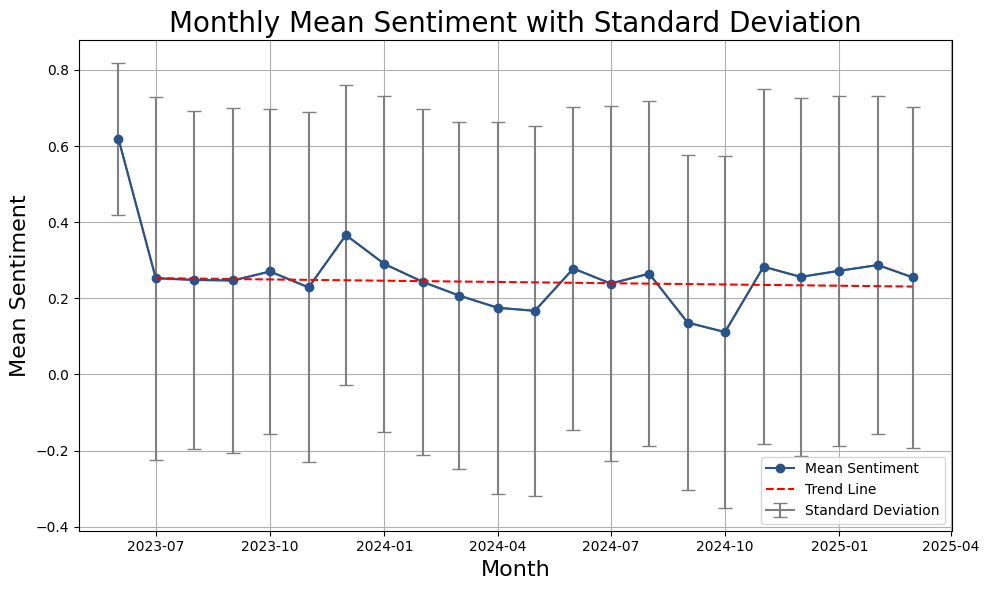

In [78]:
# Sentiment graphing with standard deviation bars
dates = dict(sorted(means.items()))
print(dates)

# Convert Period to Timestamp and then to numerical values
x_vals = [date2num(p.to_timestamp()) for p in list(dates.keys())[1:]]
y_vals = list(dates.values())[1:]
y_err = [sd[p] for p in list(dates.keys())[1:]]

# Perform linear regression
m, b = np.polyfit(x_vals, y_vals, 1)

plt.figure(figsize=(10, 6))
plt.errorbar([p.to_timestamp() for p in dates.keys()], dates.values(), 
             yerr=[sd[p] for p in dates.keys()], label='Standard Deviation', color='#808080', capsize=5)
plt.plot([p.to_timestamp() for p in dates.keys()], dates.values(), color='#27548A', marker='o', label='Mean Sentiment', zorder=3)
plt.plot([p.to_timestamp() for p in dates.keys()][1:], m * np.array(x_vals) + b, color='red', linestyle='--', label='Trend Line', zorder=4)
plt.xlabel('Month', fontdict={'fontsize': 16})
plt.ylabel('Mean Sentiment', fontdict={'fontsize': 16})
plt.title('Monthly Mean Sentiment with Standard Deviation', fontdict={'fontsize': 20})
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

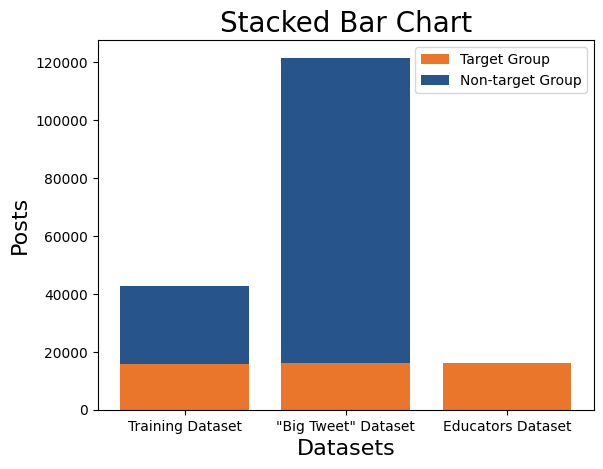

In [61]:
# Define pastel colors for the groups
pastel_colors = ['#E9762B', '#27548A']

# Stacked bar chart for the number of posts in each dataset
categories = ['Training Dataset', '"Big Tweet" Dataset', 'Educators Dataset']
subcategories = ['Target Group', 'Non-target Group']
data = np.array([[15823, 26759], [16087, 105530], [16087, 0]])

bottom = np.zeros(len(categories))

# Loop through subcategories to create bars
for i, subcategory in enumerate(subcategories):
    plt.bar(categories, data[:, i], bottom=bottom, label=subcategory, color=pastel_colors[i])
    bottom += data[:, i]

plt.xlabel('Datasets', fontdict={'fontsize': 16})
plt.ylabel('Posts', fontdict={'fontsize': 16})
plt.title('Stacked Bar Chart', fontdict={'fontsize': 20})
plt.legend(fontsize=10)
plt.show()